# Delivery-Delay Enrichment: Version 0 Proof of Concept

**The one question this notebook answers:** *Does joining cheap external context (weather, holidays, road network, calendar) to a food-delivery log make delivery-time prediction clearly better, beyond what the operator's own data already gives?*

| Section | What happens |
|---|---|
| 0 | Hypotheses and **pre-registered** success criteria |
| 1 | Setup and configuration |
| 2 | Load and clean the seed dataset (Kaggle, Indian cities) |
| 3 | Quick EDA |
| 4 | Enrichment: 4a time, 4b geo baseline, 4c holidays, 4d weather (Open-Meteo), 4e road distance (OSRM) |
| 5 | Leakage-safe temporal split, experiment design |
| 6 | Train the ablation ladder (LightGBM, regression and late/not-late) |
| 7 | Results: metrics, bootstrap CIs, grouped-by-day CV |
| 8 | Where does enrichment help? Segment analysis |
| 9 | Case studies: individual orders explained |
| 10 | Verdict against the pre-registered criteria |
| 11 | Export: the automation spec |
| 12 | How to read the outcome and next steps |

## 0. Hypotheses and pre-registered success criteria

We write the bar down **before** looking at results.

**H1 (overall):** A model trained on raw + enriched features beats the same model on raw features only, on a *future* time window.

**H2 (external data matters):** At least one truly *external* source (weather, holidays, road network) adds lift on its own. Derived features (hour-of-day, straight-line distance) don't count here: those are ordinary feature engineering any customer's data scientist can do. External enrichment is the product.

**H3 (replacement value):** For operators that do **not** log weather/traffic/festival labels (most don't), external enrichment recovers most of what those in-house labels provide.

| # | Criterion | Threshold | Tests |
|---|---|---|---|
| C1 | Relative MAE improvement, full enriched vs raw, temporal holdout | ≥ 5 % | H1 |
| C2 | Day-block bootstrap 95 % CI of MAE improvement | lower bound > 0 | H1 |
| C3 | F1 improvement on late/not-late (threshold tuned on validation) | ≥ +0.03 absolute | H1 |
| C4 | Grouped-by-day 5-fold CV: folds where enriched wins | ≥ 4 of 5 | H1 robustness |
| C5 | Some external group, when removed from the full model, worsens MAE with CI lower bound > 0 | at least one group | H2 |

C1, C2, C5 are **primary**. H3 is reported but not gating.

## 1. Setup and configuration

In [ ]:
# First run only (uncomment):
# %pip install pandas numpy lightgbm scikit-learn requests holidays matplotlib pyarrow tqdm

In [2]:
import os, re, json, time, math, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import (mean_absolute_error, f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GroupKFold

try:
    import holidays as holidays_lib
except ImportError:
    holidays_lib = None
    print("WARNING: `holidays` not installed; only the curated festival list will be used.")

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [3]:
DATA_DIR  = Path("data");    DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("cache");   CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR   = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
RAW_PATH = Path("/content/data/train.csv")

SEED = 42
SEEDS = [42, 7, 2024]          # every model is trained with each seed; test predictions are averaged
PREDICTION_POINT = "order"     # "order": ETA shown at checkout (pickup time not known during prediction -> prep time excluded)
                               # "pickup": last-mile ETA (pickup time now known during prediction -> prep time allowed)

TEST_DAY_FRACTION = 0.20       # last 20% of calendar days = test (future window)
VAL_DAY_FRACTION  = 0.15       # last 15% of remaining days = validation (for early stopping, F1 threshold)
LATE_QUANTILE     = 0.75       # "late" = delivery time above the 75th percentile of TRAIN
BOOTSTRAP_N       = 2000

# Model (identical for every feature set: fairness)
REG_OBJECTIVE = "l1"
EARLY_STOP = 200
BASE_PARAMS = dict(
    learning_rate=0.03, num_leaves=63, min_child_samples=40,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=1.0, n_estimators=5000, verbose=-1,
)

# External sources
OPEN_METEO_URL = "https://archive-api.open-meteo.com/v1/archive"
WEATHER_VARS = ["temperature_2m", "apparent_temperature", "relative_humidity_2m",
                "precipitation", "rain", "cloud_cover", "wind_speed_10m", "weather_code"]

OSRM_MODE = "off"  # "local" (docker, recommended) | "public" (demo server, ~1 req/s) | "off"
OSRM_URLS = {"local": "http://localhost:5000", "public": "https://router.project-osrm.org"}
OSRM_SLEEP_S = {"local": 0.0, "public": 1.1}
OSRM_WORKERS = {"local": 16, "public": 1}
COORD_DECIMALS = 4  # ~11 m; rounding lets identical trips share one cached route

# The public OSRM server allows about one request per second. For a full run, use local OSRM.
# In public mode the whole study runs on a random sample so every row gets real road features.
STUDY_SAMPLE = 2000 if OSRM_MODE == "public" else None

# Pre-registered success criteria
SUCCESS = dict(min_rel_mae_gain=0.05, min_f1_gain=0.03, min_cv_folds_won=4, n_cv_folds=5)

API_STATS = {"open_meteo_calls": 0, "open_meteo_cache_hits": 0,
             "osrm_calls": 0, "osrm_cache_hits": 0, "osrm_failures": 0}

In [4]:
# To save
# from google.colab import files
# files.download("outputs/enrichment_spec.json")
# files.download("outputs/enrichment_spec.md")

In [5]:
# helper functions
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = (np.radians(np.asarray(x, dtype=float)) for x in (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

def bearing_rad(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = (np.radians(np.asarray(x, dtype=float)) for x in (lat1, lon1, lat2, lon2))
    y = np.sin(lon2 - lon1) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lon2 - lon1)
    return np.arctan2(y, x)

def savefig(name):
    plt.savefig(OUT_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 2. Load and clean the seed dataset

**Dataset:** Kaggle *Food Delivery Dataset* (Indian cities, ~45k orders, Feb–Apr 2022), e.g.

```bash
kaggle datasets download -d gauravmalik26/food-delivery-dataset -p data --unzip
```

Place `train.csv` at `data/train.csv`. The slug may change; any copy with these columns works:
`ID, Delivery_person_ID, Delivery_person_Age, Delivery_person_Ratings, Restaurant_latitude, Restaurant_longitude, Delivery_location_latitude, Delivery_location_longitude, Order_Date, Time_Orderd, Time_Order_picked, Weatherconditions, Road_traffic_density, Vehicle_condition, Type_of_order, Type_of_vehicle, multiple_deliveries, Festival, City, Time_taken(min)`.

**Known quirks we handle:** padded strings and literal `"NaN "`, target stored as `"(min) 24"`, weather stored as `"conditions Sunny"`, some negative or zero coordinates, some order times stored as day fractions (`0.458333`), and a `City` column that holds a city *type* (Metropolitian / Urban / Semi-Urban), not a city. The real city is encoded in the rider ID prefix (`INDORES13DEL02` → Indore).

> ⚠️ **Caveat to keep in mind throughout:** this public dataset is widely believed to be partly synthetic. If its target was generated from its own weather/traffic labels, *real* weather can't help, and that would be a finding about the dataset, not about the idea. Section 4d checks this directly.

In [6]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"Put the Kaggle CSV at {RAW_PATH.resolve()} (see instructions above).")

raw = pd.read_csv(RAW_PATH)
print(raw.shape)
raw.head()

(45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [7]:
# City code (from rider-ID prefix) -> name, centroid, state (ISO 3166-2:IN subdivision code)
CITY_META = pd.DataFrame([
    ("INDO",   "Indore",     22.7196, 75.8577, "MP"),
    ("BANG",   "Bengaluru",  12.9716, 77.5946, "KA"),
    ("COIMB",  "Coimbatore", 11.0168, 76.9558, "TN"),
    ("CHEN",   "Chennai",    13.0827, 80.2707, "TN"),
    ("HYD",    "Hyderabad",  17.3850, 78.4867, "TG"),
    ("RANCHI", "Ranchi",     23.3441, 85.3096, "JH"),
    ("MYS",    "Mysuru",     12.2958, 76.6394, "KA"),
    ("DEH",    "Dehradun",   30.3165, 78.0322, "UK"),
    ("KOC",    "Kochi",       9.9312, 76.2673, "KL"),
    ("PUNE",   "Pune",       18.5204, 73.8567, "MH"),
    ("LUDH",   "Ludhiana",   30.9010, 75.8573, "PB"),
    ("KNP",    "Kanpur",     26.4499, 80.3319, "UP"),
    ("MUM",    "Mumbai",     19.0760, 72.8777, "MH"),
    ("KOL",    "Kolkata",    22.5726, 88.3639, "WB"),
    ("JAP",    "Jaipur",     26.9124, 75.7873, "RJ"),
    ("SUR",    "Surat",      21.1702, 72.8311, "GJ"),
    ("GOA",    "Goa",        15.4909, 73.8278, "GA"),
    ("AURG",   "Aurangabad", 19.8762, 75.3433, "MH"),
    ("AGR",    "Agra",       27.1767, 78.0081, "UP"),
    ("VAD",    "Vadodara",   22.3072, 73.1812, "GJ"),
    ("ALH",    "Prayagraj",  25.4358, 81.8463, "UP"),
    ("BHP",    "Bhopal",     23.2599, 77.4126, "MP"),
], columns=["city_code", "city_name", "city_lat", "city_lon", "state"])

In [8]:
CITY_META.head(5)

,city_code,city_name,city_lat,city_lon,state
0,INDO,Indore,22.7196,75.8577,MP
1,BANG,Bengaluru,12.9716,77.5946,KA
2,COIMB,Coimbatore,11.0168,76.9558,TN
3,CHEN,Chennai,13.0827,80.2707,TN
4,HYD,Hyderabad,17.3850,78.4867,TG


In [9]:
df = raw.copy()
df.columns = [c.strip() for c in df.columns]

def clean_text(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    return s.where(~s.isin(["NaN", "nan", "", "None", "<NA>"]), np.nan)

for c in df.columns:
    if df[c].dtype == object:
        df[c] = clean_text(df[c])

# target column
tt_col = [c for c in df.columns if c.lower().startswith("time_taken")][0]
# 24 min ---> 24
df["target_min"] = pd.to_numeric(df[tt_col].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand=False), errors="coerce")

# numerics
for c in ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries", "Vehicle_condition"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# in-house weather label ("conditions Sunny" -> "Sunny")
df["weather_label"] = clean_text(df["Weatherconditions"].astype(str).str.replace("conditions", "", regex=False))

# dates and clock times
def parse_clock_hours(x):
    # Returns hours since midnight as float. Handles "HH:MM", "HH:MM:SS" and day fractions like 0.458333.
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    s = str(x).strip()
    try:
        f = float(s)
        return f * 24.0 if 0 <= f < 1 else np.nan
    except ValueError:
        pass
    m = re.match(r"^(\d{1,2}):(\d{1,2})(?::(\d{1,2}))?$", s)
    if not m:
        return np.nan
    h, mi, se = int(m.group(1)), int(m.group(2)), int(m.group(3) or 0)
    if h > 24 or mi > 59:
        return np.nan
    return (h % 24) + mi / 60 + se / 3600

df["order_date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y", errors="coerce")
fallback = df["order_date"].isna() & df["Order_Date"].notna()
df.loc[fallback, "order_date"] = pd.to_datetime(df.loc[fallback, "Order_Date"], dayfirst=True, errors="coerce")

order_h = df["Time_Orderd"].map(parse_clock_hours).astype(float)
pick_h  = df["Time_Order_picked"].map(parse_clock_hours).astype(float)
df["order_ts"] = df["order_date"] + pd.to_timedelta(order_h, unit="h")
pick_ts = df["order_date"] + pd.to_timedelta(pick_h, unit="h")

# pickup after midnight for a late-night order
pick_ts = pick_ts.where((pick_ts >= df["order_ts"]) | df["order_ts"].isna(), pick_ts + pd.Timedelta(days=1))
df["prep_min"] = (pick_ts - df["order_ts"]).dt.total_seconds() / 60
df.loc[(df["prep_min"] < 0) | (df["prep_min"] > 120), "prep_min"] = np.nan

# Event time used for joins: order time; if missing, pickup minus a typical prep time (10 mins here)
df["event_ts"] = df["order_ts"].fillna(pick_ts - pd.Timedelta(minutes=10))
df["event_hour_f"] = df["event_ts"].dt.hour + df["event_ts"].dt.minute / 60

# coordinates: fix sign, drop placeholders and anything outside India's bounding box
COORD_PAIRS = [("Restaurant_latitude", "Restaurant_longitude"),
               ("Delivery_location_latitude", "Delivery_location_longitude")]

for la, lo in COORD_PAIRS:
    df[la] = pd.to_numeric(df[la], errors="coerce").abs()
    df[lo] = pd.to_numeric(df[lo], errors="coerce").abs()
    bad = ~(df[la].between(6, 37.5) & df[lo].between(68, 97.5)) # anything outside India's geographic coordinates is considered invalid
    df.loc[bad, [la, lo]] = np.nan

# real city from rider ID
df["city_code"] = df["Delivery_person_ID"].astype(str).str.extract(r"^([A-Z]+?)RES", expand=False)
df = df.merge(CITY_META, on="city_code", how="left")
print("Unmapped city codes:", df.loc[df["city_name"].isna(), "city_code"].value_counts().to_dict())

# coordinates > 60 km from their city's centre are mismatched, so null them
for la, lo in COORD_PAIRS:
    far = haversine_km(df[la], df[lo], df["city_lat"], df["city_lon"]) > 60
    df.loc[far, [la, lo]] = np.nan

# final filtering
n0 = len(df)
df = (df.dropna(subset=["target_min", "order_date", "event_ts", "city_code", "city_lat"]).drop_duplicates("ID").reset_index(drop=True))
print(f"Rows: {n0:,} -> {len(df):,} after cleaning")

if STUDY_SAMPLE is not None and len(df) > STUDY_SAMPLE:
    df = df.sample(STUDY_SAMPLE, random_state=SEED).reset_index(drop=True)
    print(f"Sampled {len(df):,} rows for OSRM_MODE='{OSRM_MODE}'")

df[["ID", "city_name", "state", "order_ts", "prep_min", "weather_label",
    "Road_traffic_density", "Festival", "target_min"]].head()

Unmapped city codes: {}
Rows: 45,593 -> 45,593 after cleaning


,ID,city_name,state,order_ts,prep_min,weather_label,Road_traffic_density,Festival,target_min
0,0x4607,Indore,MP,2022-03-19 11:30:00,15.0,Sunny,High,No,24
1,0xb379,Bengaluru,KA,2022-03-25 19:45:00,5.0,Stormy,Jam,No,33
2,0x5d6d,Bengaluru,KA,2022-03-19 08:30:00,15.0,Sandstorms,Low,No,26
3,0x7a6a,Coimbatore,TN,2022-04-05 18:00:00,10.0,Sunny,Medium,No,21
4,0x70a2,Chennai,TN,2022-03-26 13:30:00,15.0,Cloudy,High,No,30


In [10]:
df.shape

(45593, 32)

In [11]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),target_min,weather_label,order_date,order_ts,prep_min,event_ts,event_hour_f,city_code,city_name,city_lat,city_lon,state
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24,24,Sunny,2022-03-19,2022-03-19 11:30:00,15.0,2022-03-19 11:30:00,11.50,INDO,Indore,22.7196,75.8577,MP
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33,33,Stormy,2022-03-25,2022-03-25 19:45:00,5.0,2022-03-25 19:45:00,19.75,BANG,Bengaluru,12.9716,77.5946,KA
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26,26,Sandstorms,2022-03-19,2022-03-19 08:30:00,15.0,2022-03-19 08:30:00,8.50,BANG,Bengaluru,12.9716,77.5946,KA
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21,21,Sunny,2022-04-05,2022-04-05 18:00:00,10.0,2022-04-05 18:00:00,18.00,COIMB,Coimbatore,11.0168,76.9558,TN
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30,30,Cloudy,2022-03-26,2022-03-26 13:30:00,15.0,2022-03-26 13:30:00,13.50,CHEN,Chennai,13.0827,80.2707,TN


In [12]:
# Data-quality report: this also becomes part of the automation spec (what cleaning is needed)
dq = pd.DataFrame({
    "missing_%": df.isna().mean().mul(100).round(1),
    "n_unique": df.nunique(),
}).loc[["target_min", "order_ts", "prep_min", "Restaurant_latitude", "Delivery_location_latitude",
        "weather_label", "Road_traffic_density", "Festival", "multiple_deliveries",
        "Delivery_person_Ratings", "city_code"]]
print(f"Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()} "
      f"({df['order_date'].nunique()} distinct days), cities: {df['city_code'].nunique()}")
dq

Date range: 2022-02-11 -> 2022-04-06 (44 distinct days), cities: 22


,missing_%,n_unique
target_min,0.0,45
order_ts,3.8,5503
prep_min,3.8,7
Restaurant_latitude,8.0,388
Delivery_location_latitude,8.0,4362
weather_label,1.4,6
Road_traffic_density,1.3,4
Festival,0.5,2
multiple_deliveries,2.2,4
Delivery_person_Ratings,4.2,28


## 3. EDA

We only want to know the shape of the problem: target distribution, where the data comes from, and whether the calendar has gaps that affect our split.

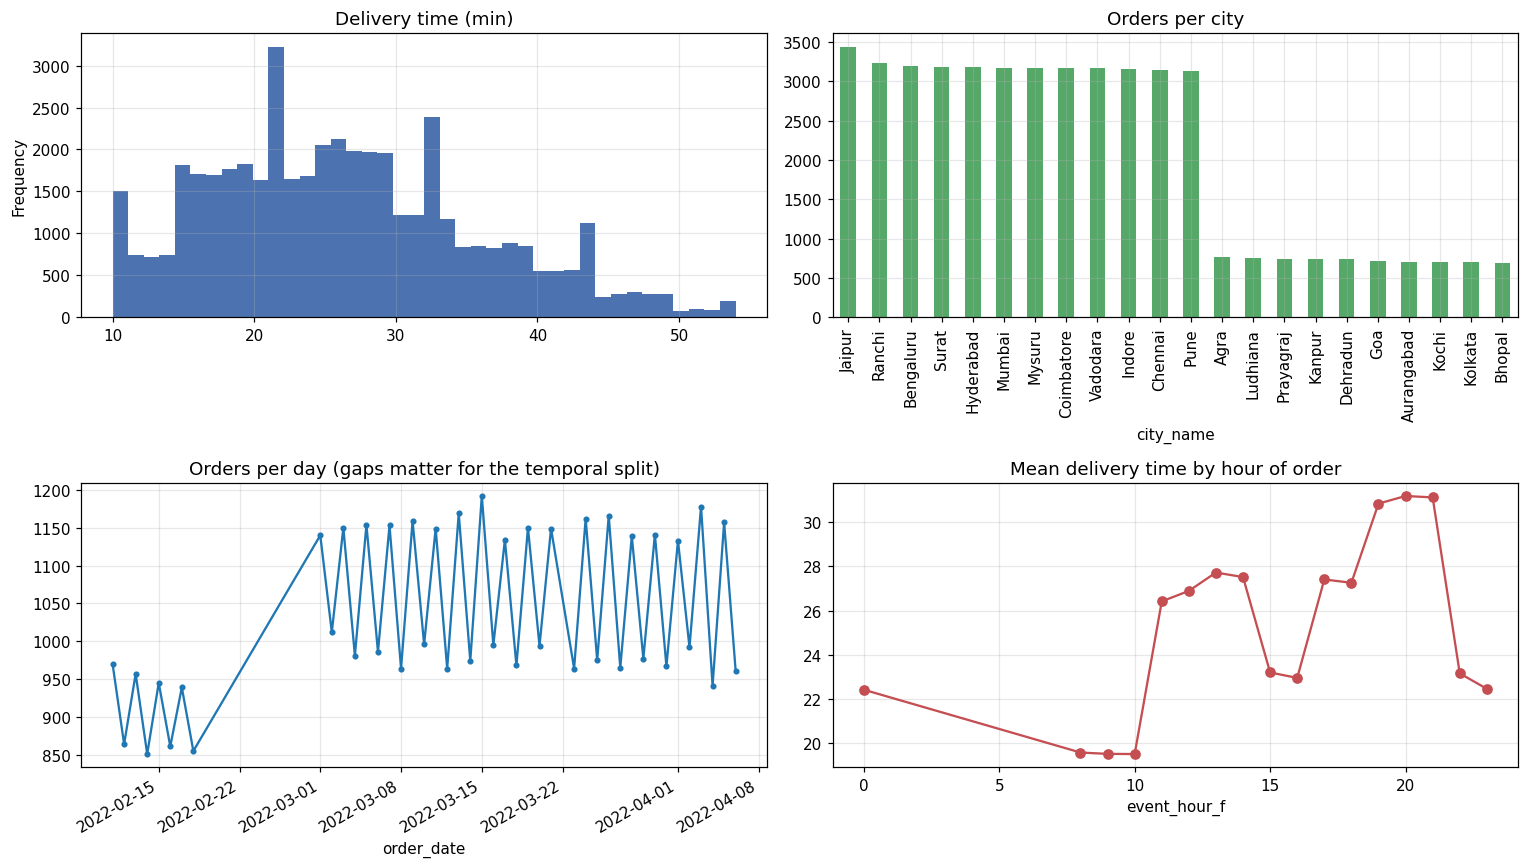

               count  mean
weather_label             
Cloudy          7536  28.9
Fog             7654  28.9
Sandstorms      7495  25.9
Stormy          7586  25.9
Sunny           7284  21.9
Windy           7422  26.1
                      count  mean
Road_traffic_density             
High                   4425  27.2
Jam                   14143  31.2
Low                   15477  21.3
Medium                10947  26.7


In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

df["target_min"].plot.hist(bins=40, ax=ax[0, 0], color="#4C72B0")
ax[0, 0].set_title("Delivery time (min)")

df["city_name"].value_counts().plot.bar(ax=ax[0, 1], color="#55A868")
ax[0, 1].set_title("Orders per city")

df.groupby("order_date").size().plot(ax=ax[1, 0], marker=".")
ax[1, 0].set_title("Orders per day (gaps matter for the temporal split)")

df.groupby(df["event_hour_f"].floordiv(1))["target_min"].mean().plot(ax=ax[1, 1], marker="o", color="#C44E52")
ax[1, 1].set_title("Mean delivery time by hour of order")
plt.tight_layout(); savefig("eda_overview"); plt.show()

print(df.groupby("weather_label")["target_min"].agg(["count", "mean"]).round(1))
print(df.groupby("Road_traffic_density")["target_min"].agg(["count", "mean"]).round(1))

## 4. Enrichment

Every feature belongs to exactly one **group**.
| Group | Prefix | Type | Source |
|---|---|---|---|
| `raw` | none | the customer's own log | the dataset as delivered (minimal type coercion only) |
| `time` | `t_` | derived | order timestamp |
| `geo` | `g_` | derived | straight-line distance, bearing, distance to city centre |
| `holiday` | `h_` | **external** | `python-holidays` (national + state) + curated regional festival list |
| `weather` | `w_` | **external** | Open-Meteo historical archive, hourly, per city |
| `road` | `r_` | **external** | OSRM routing on OpenStreetMap |

Deliberately separating *derived* (`time`, `geo`) from *external* groups is what lets us test H2.

In [14]:
RAW_NUM = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition", "multiple_deliveries",
           "Restaurant_latitude", "Restaurant_longitude",
           "Delivery_location_latitude", "Delivery_location_longitude"]
RAW_CAT = ["weather_label", "Road_traffic_density", "Type_of_order", "Type_of_vehicle", "Festival", "City", "city_code"]

# Context labels most real operators do NOT log. Used to test H3 (replacement value).
INHOUSE_CONTEXT = ["weather_label", "Road_traffic_density", "Festival"]

CATEGORICAL = set(RAW_CAT)
FEATURE_GROUPS = {"raw": RAW_NUM + RAW_CAT}

### 4a. Time-of-day and calendar features (derived)

Cyclic encodings for hour and weekday, meal periods, and salary-week effect (start/end of month).
`t_prep_min` is included **only** when `PREDICTION_POINT == "pickup"`: at checkout we do not yet know when the restaurant will hand over the food, so using it would be data leakage.

In [15]:
h = df["event_hour_f"]
df["t_hour"] = np.floor(h)

# 0 and 23 hours, the model may consider them to be far apart in time whereas they are consecutive
df["t_hour_sin"] = np.sin(2 * np.pi * h / 24)
df["t_hour_cos"] = np.cos(2 * np.pi * h / 24)

df["t_dow"] = df["order_date"].dt.dayofweek
df["t_dow_sin"] = np.sin(2 * np.pi * df["t_dow"] / 7)
df["t_dow_cos"] = np.cos(2 * np.pi * df["t_dow"] / 7)

df["t_is_weekend"] = (df["t_dow"] >= 5).astype(int)
df["t_day_of_month"] = df["order_date"].dt.day
df["t_salary_window"] = ((df["t_day_of_month"] <= 3) | (df["t_day_of_month"] >= 28)).astype(int)

df["t_meal_period"] = np.select(
    [h.between(6, 11, inclusive="left"), h.between(11, 15, inclusive="left"),
     h.between(15, 18.5, inclusive="left"), h.between(18.5, 23, inclusive="left")],
    ["breakfast", "lunch", "evening_snack", "dinner"], default="late_night")

df["t_is_peak"] = (h.between(12, 14.5) | h.between(19, 22)).astype(int)
df["t_prep_min"] = df["prep_min"]

TIME_FEATS = ["t_hour", "t_hour_sin", "t_hour_cos", "t_dow", "t_dow_sin", "t_dow_cos",
              "t_is_weekend", "t_day_of_month", "t_salary_window", "t_meal_period", "t_is_peak"]
if PREDICTION_POINT == "pickup":
    TIME_FEATS.append("t_prep_min")
CATEGORICAL.add("t_meal_period")
FEATURE_GROUPS["time"] = TIME_FEATS
print("Time features:", TIME_FEATS)

Time features: ['t_hour', 't_hour_sin', 't_hour_cos', 't_dow', 't_dow_sin', 't_dow_cos', 't_is_weekend', 't_day_of_month', 't_salary_window', 't_meal_period', 't_is_peak']


### 4b. Geo baseline (derived): straight-line distance

This is the **bar the road network has to beat**. If OSRM road distance adds nothing beyond haversine, we shouldn't pay to run routing in production.

In [16]:
rl, rn = df["Restaurant_latitude"], df["Restaurant_longitude"]
dl, dn = df["Delivery_location_latitude"], df["Delivery_location_longitude"]

df["g_haversine_km"] = haversine_km(rl, rn, dl, dn)
df.loc[df["g_haversine_km"] > 40, "g_haversine_km"] = np.nan   # implausible for food delivery
b = bearing_rad(rl, rn, dl, dn)
df["g_bearing_sin"], df["g_bearing_cos"] = np.sin(b), np.cos(b)
df["g_rest_to_center_km"] = haversine_km(rl, rn, df["city_lat"], df["city_lon"])
df["g_drop_to_center_km"] = haversine_km(dl, dn, df["city_lat"], df["city_lon"])

GEO_FEATS = ["g_haversine_km", "g_bearing_sin", "g_bearing_cos", "g_rest_to_center_km", "g_drop_to_center_km"]
FEATURE_GROUPS["geo"] = GEO_FEATS
df[GEO_FEATS].describe().round(2)

,g_haversine_km,g_bearing_sin,g_bearing_cos,g_rest_to_center_km,g_drop_to_center_km
count,41953.00,41953.00,41953.00,41953.00,41953.00
mean,9.72,0.69,0.73,5.55,11.75
std,5.60,0.01,0.01,4.05,6.20
min,1.47,0.65,0.71,0.17,0.14
25%,4.66,0.68,0.72,2.77,6.79
50%,9.19,0.69,0.73,4.58,11.16
75%,13.68,0.70,0.74,6.62,15.95
max,20.97,0.70,0.76,39.31,38.64


### 4c. Indian public holidays and festivals (external)

Two layers:
1. **`python-holidays`** for national and state gazetted holidays (state from the city mapping).
2. **A curated festival list** for 2022, because lunar/regional festivals (Holi, Ugadi, Ram Navami…) are what actually move food demand, and library coverage varies by version. *Verify dates against the official calendar before reusing.* This curated list is itself a lesson for the product: **maintaining a regional festival calendar is real, recurring work, and part of the moat.**

What it does?

>Order date + State:        
- Use External holiday sources - python-holidays, curated festivals
        
- Holiday context
        
        - Is today a holiday?
        - Is it national?
        - How close is the next holiday?
        - How close was the previous holiday?
        - Is it around a holiday?
        - Is it a long weekend?
        - s it Ramadan/iftar?

In [17]:
# (date, name, scope) where scope is "ALL" or comma-separated state codes. 2022 dates; VERIFY before reuse.
CURATED_FESTIVALS = [
    ("2022-01-26", "Republic Day", "ALL"),
    ("2022-03-01", "Maha Shivaratri", "ALL"),
    ("2022-03-17", "Holika Dahan", "ALL"),
    ("2022-03-18", "Holi", "ALL"),
    ("2022-04-02", "Ugadi / Gudi Padwa", "KA,MH,TG,GA"),
    ("2022-04-10", "Ram Navami", "ALL"),
    ("2022-04-14", "Ambedkar Jayanti / Mahavir Jayanti / Tamil New Year / Baisakhi", "ALL"),
    ("2022-04-15", "Good Friday", "ALL"),
    ("2022-05-03", "Eid al-Fitr", "ALL"),
]
RAMADAN_2022 = (pd.Timestamp("2022-04-03"), pd.Timestamp("2022-05-02"))
SUBDIV_ALIASES = {"TG": ["TG", "TS"], "UK": ["UK", "UT"]}   # codes differ between library versions

years = sorted(df["order_date"].dt.year.unique().tolist())
states = sorted(df["state"].dropna().unique().tolist())

def lib_holidays(state=None):
    if holidays_lib is None:
        return {}
    for code in (SUBDIV_ALIASES.get(state, [state]) if state else [None]):
        try:
            h = holidays_lib.country_holidays("IN", subdiv=code, years=years)
            return {pd.Timestamp(d): n for d, n in h.items()}
        except Exception:
            continue
    print(f"  python-holidays: subdivision {state} unsupported, using national + curated only")
    return {}

national = lib_holidays(None)
curated_all = {pd.Timestamp(d): n for d, n, s in CURATED_FESTIVALS if s == "ALL"}
national_dates = set(national) | set(curated_all)

calendar = {}
for st in states:
    curated_st = {pd.Timestamp(d): n for d, n, s in CURATED_FESTIVALS if s != "ALL" and st in s.split(",")}
    calendar[st] = {**national, **curated_all, **lib_holidays(st), **curated_st}

# Build a (date, state) feature table, then merge. Cheap: ~days x states rows.
all_days = pd.date_range(df["order_date"].min() - pd.Timedelta(days=3),
                         df["order_date"].max() + pd.Timedelta(days=3), freq="D")
rows = []
for st, hmap in calendar.items():
    hset = set(hmap)
    hdates = np.array(sorted(hset), dtype="datetime64[D]")
    is_off = lambda d: d.dayofweek >= 5 or d in hset
    for d in all_days:
        d64 = np.datetime64(d.date())
        i = np.searchsorted(hdates, d64, side="left")
        j = np.searchsorted(hdates, d64, side="right") - 1
        to_next = int((hdates[i] - d64).astype(int)) if i < len(hdates) else 30
        since_prev = int((d64 - hdates[j]).astype(int)) if j >= 0 else 30
        near_holiday = any((d + pd.Timedelta(days=k)) in hset for k in range(-2, 3))
        rows.append({
            "order_date": d, "state": st,
            "h_is_holiday": int(d in hset),
            "h_is_national": int(d in national_dates),
            "h_name": hmap.get(d, None),
            "h_days_to_next": min(to_next, 30),
            "h_days_since_prev": min(since_prev, 30),
            "h_in_window": int(min(to_next, since_prev) <= 1),
            "h_long_weekend": int(is_off(d) and (is_off(d - pd.Timedelta(days=1)) or is_off(d + pd.Timedelta(days=1)))
                                  and near_holiday),
        })
hol_table = pd.DataFrame(rows)

df = df.drop(columns=[c for c in hol_table.columns if c.startswith("h_")], errors="ignore")
df = df.merge(hol_table, on=["order_date", "state"], how="left")
df["h_is_ramadan"] = df["order_date"].between(*RAMADAN_2022).astype(int)
df["h_iftar_window"] = (df["h_is_ramadan"].eq(1) & df["event_hour_f"].between(18, 20)).astype(int)

HOL_FEATS = ["h_is_holiday", "h_is_national", "h_days_to_next", "h_days_since_prev",
             "h_in_window", "h_long_weekend", "h_is_ramadan", "h_iftar_window"]
FEATURE_GROUPS["holiday"] = HOL_FEATS

print("Holidays that fall inside the data window:")
print(df.loc[df["h_is_holiday"] == 1].groupby(["order_date", "h_name"]).size().rename("orders").to_string())
print("\nIn-house 'Festival' flag vs our holiday window (agreement check):")
print(pd.crosstab(df["Festival"], df["h_in_window"], margins=True))

Holidays that fall inside the data window:
order_date  h_name            
2022-03-01  Maha Shivaratri       1140
2022-03-17  Holika Dahan          1134
2022-03-18  Holi                   968
2022-03-30  Rajasthan Day           95
2022-04-02  Ugadi / Gudi Padwa     400

In-house 'Festival' flag vs our holiday window (agreement check):
h_in_window      0     1    All
Festival                       
No           36542  7927  44469
Yes            750   146    896
All          37292  8073  45365


### 4d. Historical weather: Open-Meteo archive (external)

Free, no key, hourly. One request per city covering the whole date range, cached to disk. Join key: `(city, hour)`.

**Point-in-time note:** the archive is reanalysis ("what actually happened"). In production we'd use a *forecast/nowcast* issued before the order. Reanalysis is therefore slightly optimistic; we flag `w_precip_next1h` explicitly as a forecast proxy.

**Hour alignment:** Open-Meteo's hourly `precipitation` at time *T* is the total over the preceding hour, so we join on the order time **rounded up** to the hour: the value covering the hour in which the order was placed.

In [18]:
def fetch_open_meteo(city_code, lat, lon, start, end):
    cache = CACHE_DIR / f"openmeteo_{city_code}_{start}_{end}.json"
    if cache.exists():
        API_STATS["open_meteo_cache_hits"] += 1
        return json.loads(cache.read_text())
    params = dict(latitude=lat, longitude=lon, start_date=start, end_date=end,
                  hourly=",".join(WEATHER_VARS), timezone="Asia/Kolkata")
    for attempt in range(5):
        API_STATS["open_meteo_calls"] += 1
        r = requests.get(OPEN_METEO_URL, params=params, timeout=60)
        if r.status_code == 200:
            data = r.json()
            cache.write_text(json.dumps(data))
            return data
        time.sleep(2 ** attempt)
    r.raise_for_status()

start = (df["event_ts"].min().normalize() - pd.Timedelta(days=2)).strftime("%Y-%m-%d")
end = (df["event_ts"].max().normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

frames = []
for row in tqdm(CITY_META[CITY_META["city_code"].isin(df["city_code"].unique())].itertuples(),
                desc="Open-Meteo"):
    js = fetch_open_meteo(row.city_code, row.city_lat, row.city_lon, start, end)
    hourly = pd.DataFrame(js["hourly"])
    hourly["time"] = pd.to_datetime(hourly["time"])
    hourly["city_code"] = row.city_code
    frames.append(hourly)

wx = pd.concat(frames, ignore_index=True).sort_values(["city_code", "time"])
g = wx.groupby("city_code")["precipitation"]
wx["precip_3h"] = g.transform(lambda s: s.rolling(3, min_periods=1).sum())
wx["precip_24h"] = g.transform(lambda s: s.rolling(24, min_periods=1).sum())
wx["precip_next1h"] = g.shift(-1)          # forecast proxy
wx["temp_vs_city_day_mean"] = wx["temperature_2m"] - wx.groupby(
    ["city_code", wx["time"].dt.date])["temperature_2m"].transform("mean")

wx = wx.rename(columns={
    "temperature_2m": "w_temp_c", "apparent_temperature": "w_feels_like_c",
    "relative_humidity_2m": "w_humidity", "precipitation": "w_precip_mm", "rain": "w_rain_mm",
    "cloud_cover": "w_cloud_pct", "wind_speed_10m": "w_wind_kmh", "weather_code": "w_wmo_code",
    "precip_3h": "w_precip_3h_mm", "precip_24h": "w_precip_24h_mm",
    "precip_next1h": "w_precip_next1h_mm", "temp_vs_city_day_mean": "w_temp_anomaly_day",
})

df["join_hour"] = df["event_ts"].dt.ceil("h")
df = df.drop(columns=[c for c in df.columns if c.startswith("w_")], errors="ignore")
df = df.merge(wx.rename(columns={"time": "join_hour"}), on=["city_code", "join_hour"], how="left")

def flag(series, thr):
    return series.ge(thr).astype(float).where(series.notna())

df["w_is_rain"] = flag(df["w_precip_mm"], 0.2)
df["w_heavy_rain"] = flag(df["w_precip_mm"], 2.5)
df["w_rained_last_3h"] = flag(df["w_precip_3h_mm"], 0.5)
df["w_hot"] = flag(df["w_feels_like_c"], 38)
df["w_wmo_code"] = df["w_wmo_code"].astype("Int64").astype(str).replace("<NA>", np.nan)

WX_FEATS = ["w_temp_c", "w_feels_like_c", "w_humidity", "w_precip_mm", "w_rain_mm", "w_cloud_pct",
            "w_wind_kmh", "w_wmo_code", "w_precip_3h_mm", "w_precip_24h_mm", "w_precip_next1h_mm",
            "w_temp_anomaly_day", "w_is_rain", "w_heavy_rain", "w_rained_last_3h", "w_hot"]
CATEGORICAL.add("w_wmo_code")
FEATURE_GROUPS["weather"] = WX_FEATS
print(f"Weather coverage: {df['w_temp_c'].notna().mean():.1%} of orders; "
      f"orders with rain at order hour: {df['w_is_rain'].mean():.1%}")

Open-Meteo: 0it [00:00, ?it/s]

Weather coverage: 100.0% of orders; orders with rain at order hour: 0.6%


#### Sanity check: does the dataset's own weather label match reality?

If "Stormy" orders in the dataset show **no more real rain** than "Sunny" ones, the in-house labels are synthetic or random. That means (a) the dataset's target may be generated from fake labels, and (b) real weather cannot be expected to help *on this dataset*. That wouldn't refute the product; it'd tell us to validate on real operator logs.

In [19]:
check = (df.groupby("weather_label")
           .agg(orders=("ID", "size"),
                real_rain_share=("w_is_rain", "mean"),
                real_precip_mm=("w_precip_mm", "mean"),
                real_cloud_pct=("w_cloud_pct", "mean"),
                real_wind_kmh=("w_wind_kmh", "mean"),
                mean_delivery_min=("target_min", "mean"))
           .round(3).sort_values("real_rain_share"))
display(check)

spread = check["real_rain_share"].max() - check["real_rain_share"].min()
LABELS_LOOK_REAL = spread > 0.10
print(f"Spread of real rain share across in-house labels: {spread:.3f} -> "
      + ("labels track real weather." if LABELS_LOOK_REAL
         else "labels do NOT track real weather; treat this dataset's weather labels as synthetic."))

,orders,real_rain_share,real_precip_mm,real_cloud_pct,real_wind_kmh,mean_delivery_min
weather_label,,,,,,
Fog,7654,0.005,0.003,22.333,10.159,28.916
Sandstorms,7495,0.005,0.003,22.546,10.169,25.876
Stormy,7586,0.005,0.003,22.580,10.191,25.871
Windy,7422,0.005,0.004,21.748,10.134,26.119
Sunny,7284,0.007,0.005,22.840,10.119,21.857
Cloudy,7536,0.008,0.006,22.448,10.169,28.917


Spread of real rain share across in-house labels: 0.003 -> labels do NOT track real weather; treat this dataset's weather labels as synthetic.


### 4e. Road distance and free-flow duration: OSRM on OpenStreetMap (external)

**Recommended: local OSRM** (fast, no rate limit):

```bash
# Whole-India extract is large and pre-processing needs a lot of RAM; Geofabrik also offers smaller India zone extracts.
wget https://download.geofabrik.de/asia/india-latest.osm.pbf
docker run -t -v "${PWD}:/data" ghcr.io/project-osrm/osrm-backend osrm-extract -p /opt/car.lua /data/india-latest.osm.pbf
docker run -t -v "${PWD}:/data" ghcr.io/project-osrm/osrm-backend osrm-partition /data/india-latest.osrm
docker run -t -v "${PWD}:/data" ghcr.io/project-osrm/osrm-backend osrm-customize /data/india-latest.osrm
docker run -t -p 5000:5000 -v "${PWD}:/data" ghcr.io/project-osrm/osrm-backend osrm-routed --algorithm mld /data/india-latest.osrm
```

The public demo server (`OSRM_MODE="public"`) works for a sample only: it's rate-limited and not meant for bulk use.

**Caveat:** OSRM's default profile is `car`; most Indian food delivery is by two-wheeler. Road *distance* transfers well; free-flow *duration* is only a prior the model recalibrates.

Features: road km, OSRM free-flow minutes, **detour ratio** (road ÷ straight line, which captures rivers, rail lines, flyovers and one-way systems) and implied free-flow speed.

In [20]:
ROAD_ON = OSRM_MODE in ("local", "public")
ROUTE_CACHE = CACHE_DIR / "osrm_routes.parquet"

def pair_key(a, b, c, d):
    return f"{a:.{COORD_DECIMALS}f},{b:.{COORD_DECIMALS}f},{c:.{COORD_DECIMALS}f},{d:.{COORD_DECIMALS}f}"

_session = requests.Session()

def osrm_route(lat1, lon1, lat2, lon2):
    url = f"{OSRM_URLS[OSRM_MODE]}/route/v1/driving/{lon1},{lat1};{lon2},{lat2}"
    for attempt in range(3):
        try:
            API_STATS["osrm_calls"] += 1
            r = _session.get(url, params={"overview": "false", "alternatives": "false", "steps": "false"},
                             timeout=20)
            if r.status_code == 429:
                time.sleep(5 * (attempt + 1)); continue
            if r.status_code != 200:
                break
            js = r.json()
            if js.get("code") == "Ok" and js.get("routes"):
                rt = js["routes"][0]
                return rt["distance"], rt["duration"]
            break
        except requests.RequestException:
            time.sleep(2 ** attempt)
    API_STATS["osrm_failures"] += 1
    return np.nan, np.nan

if ROAD_ON:
    ok = df[["Restaurant_latitude", "Restaurant_longitude",
             "Delivery_location_latitude", "Delivery_location_longitude"]].notna().all(axis=1)
    coords = df.loc[ok, ["Restaurant_latitude", "Restaurant_longitude",
                         "Delivery_location_latitude", "Delivery_location_longitude"]].round(COORD_DECIMALS)
    df["route_key"] = np.nan
    df.loc[ok, "route_key"] = [pair_key(*r) for r in coords.itertuples(index=False)]

    cache = pd.read_parquet(ROUTE_CACHE) if ROUTE_CACHE.exists() else \
        pd.DataFrame(columns=["route_key", "road_m", "osrm_s"])
    done = set(cache["route_key"])
    todo = [k for k in df["route_key"].dropna().unique() if k not in done]
    API_STATS["osrm_cache_hits"] = int(df["route_key"].dropna().nunique() - len(todo))
    print(f"Unique routes: {df['route_key'].nunique():,} | cached: {API_STATS['osrm_cache_hits']:,} "
          f"| to fetch: {len(todo):,} via {OSRM_MODE}")

    new_rows = []
    def work(k):
        a, b, c, d = map(float, k.split(","))
        dist, dur = osrm_route(a, b, c, d)
        time.sleep(OSRM_SLEEP_S[OSRM_MODE])
        return {"route_key": k, "road_m": dist, "osrm_s": dur}

    def flush():
        global cache, new_rows
        if new_rows:
            cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
            cache.to_parquet(ROUTE_CACHE, index=False)
            new_rows = []

    with ThreadPoolExecutor(max_workers=OSRM_WORKERS[OSRM_MODE]) as ex:
        futures = [ex.submit(work, k) for k in todo]
        for i, fut in enumerate(tqdm(as_completed(futures), total=len(futures), desc="OSRM")):
            new_rows.append(fut.result())
            if (i + 1) % 500 == 0:
                flush()
    flush()

    df = df.drop(columns=["road_m", "osrm_s"], errors="ignore").merge(cache, on="route_key", how="left")
    df["r_road_km"] = df["road_m"] / 1000
    df["r_osrm_min"] = df["osrm_s"] / 60
    df["r_detour_ratio"] = (df["r_road_km"] / df["g_haversine_km"]).where(df["g_haversine_km"] > 0.2).clip(1, 5)
    df["r_osrm_speed_kmh"] = (df["r_road_km"] / (df["r_osrm_min"] / 60)).where(df["r_osrm_min"] > 0)
    ROAD_FEATS = ["r_road_km", "r_osrm_min", "r_detour_ratio", "r_osrm_speed_kmh"]
    print(f"Road coverage: {df['r_road_km'].notna().mean():.1%} | median detour ratio: "
          f"{df['r_detour_ratio'].median():.2f}")
else:
    ROAD_FEATS = []
    print("OSRM_MODE='off': road group skipped.")

FEATURE_GROUPS["road"] = ROAD_FEATS

OSRM_MODE='off': road group skipped.


In [21]:
# Coverage summary per group: an input to the automation spec
coverage = {g: float(df[f].notna().any(axis=1).mean()) if f else 0.0 for g, f in FEATURE_GROUPS.items()}
FEAT2GROUP = {f: g for g, fs in FEATURE_GROUPS.items() for f in fs}
pd.Series(coverage, name="row coverage").map("{:.1%}".format)

,row coverage
raw,100.0%
time,100.0%
geo,92.0%
holiday,100.0%
weather,100.0%
road,0.0%


## 5. Split and experiment design

### Leakage and fairness checklist
- Temporal split by calendar day. Train on the past, test on a future window.
- Validation carved from the end of train
- Same model, same hyperparameters, same seeds for every feature set. Only the columns change.
- No target-derived features. The late threshold comes from the *train* distribution.
- Prep time excluded at `PREDICTION_POINT="order"`.
- Weather is reanalysis (optimistic vs a real forecast), and this is noted in the verdict.
- Categorical levels are fixed from the full dataset (labels only, no target information).

In [22]:
days = np.sort(df["order_date"].unique())
n_test = max(1, int(round(len(days) * TEST_DAY_FRACTION)))
test_days = days[-n_test:]
rest = days[:-n_test]
n_val = max(1, int(round(len(rest) * VAL_DAY_FRACTION)))
val_days = rest[-n_val:]

df["split"] = np.where(df["order_date"].isin(test_days), "test",
               np.where(df["order_date"].isin(val_days), "val", "train"))

late_thr = df.loc[df["split"] == "train", "target_min"].quantile(LATE_QUANTILE)
df["is_late"] = (df["target_min"] > late_thr).astype(int)
print(f"'Late' = delivery > {late_thr:.0f} min (train P{int(LATE_QUANTILE*100)})")

split_summary = df.groupby("split").agg(
    rows=("ID", "size"), first_day=("order_date", "min"), last_day=("order_date", "max"),
    days=("order_date", "nunique"), late_rate=("is_late", "mean"),
    holiday_rows=("h_in_window", "sum"), rain_rows=("w_is_rain", "sum"),
).loc[["train", "val", "test"]]
display(split_summary)

if split_summary.loc["test", "holiday_rows"] == 0:
    print("NOTE: no holiday-window orders in the test window, so the holiday effect cannot show on the "
          "temporal holdout. The grouped-by-day CV in Section 7 covers this.")
if split_summary.loc["test", "rain_rows"] < 50:
    print("NOTE: very little rain in the test window (dry season). Expect weather lift to be small on "
          "holdout. This is a data-coverage limit, not necessarily a feature failure.")

'Late' = delivery > 33 min (train P75)


,rows,first_day,last_day,days,late_rate,holiday_rows,rain_rows
split,,,,,,,
train,30739,2022-02-11,2022-03-23,30,0.222714,6477,176.0
val,5407,2022-03-24,2022-03-28,5,0.186610,0,37.0
test,9447,2022-03-29,2022-04-06,9,0.228115,1637,59.0


- Does feature engineering help? - M0 → M1 → M2
- Does external enrichment help? - M2 → M3 → M4 → M5
- Does each external source matter? - H2, C5
- Can enrichment compensate for missing internal context? - H3
- What's the pure external-data contribution?

In [23]:
def feats_of(*groups, drop=()):
    out = []
    for g in groups:
        for f in FEATURE_GROUPS[g]:
            if f not in out and f not in drop:
                out.append(f)
    return out

EXTERNAL = ["holiday", "weather"] + (["road"] if ROAD_ON else [])
ALL_GROUPS = ["raw", "time", "geo"] + EXTERNAL

EXPERIMENTS = {
    "M0_raw":                 feats_of("raw"),
    "M0b_raw_no_inhouse_ctx": feats_of("raw", drop=INHOUSE_CONTEXT),
    "M1_+time":               feats_of("raw", "time"),
    "M2_+geo":                feats_of("raw", "time", "geo"),
    "M3_+holiday":            feats_of("raw", "time", "geo", "holiday"),
    "M4_+weather":            feats_of("raw", "time", "geo", "holiday", "weather"),
}
if ROAD_ON:
    EXPERIMENTS["M5_+road"] = feats_of(*ALL_GROUPS)
BASELINE = "M0_raw"
FULL = list(EXPERIMENTS)[-1]
LADDER = list(EXPERIMENTS)                      # cumulative ladder (for the waterfall chart)

EXPERIMENTS["M6_full_no_inhouse_ctx"] = feats_of(*ALL_GROUPS, drop=INHOUSE_CONTEXT)       # H3
EXPERIMENTS["X_raw+external_only"] = feats_of("raw", *EXTERNAL)                            # H2, without our own FE
for g in ["time", "geo"] + EXTERNAL:                                                       # leave-one-group-out
    EXPERIMENTS[f"LOO_full_minus_{g}"] = [f for f in EXPERIMENTS[FULL] if f not in FEATURE_GROUPS[g]]

ALL_FEATS = sorted({f for fs in EXPERIMENTS.values() for f in fs})
CAT_LEVELS = {c: sorted(df[c].dropna().astype(str).unique()) for c in ALL_FEATS if c in CATEGORICAL}
for c in CAT_LEVELS:
    df[c] = df[c].where(df[c].isna(), df[c].astype(str))

pd.DataFrame({"n_features": {k: len(v) for k, v in EXPERIMENTS.items()}})

,n_features
M0_raw,15
M0b_raw_no_inhouse_ctx,12
M1_+time,26
M2_+geo,31
M3_+holiday,39
M4_+weather,55
M6_full_no_inhouse_ctx,52
X_raw+external_only,39
LOO_full_minus_time,44
LOO_full_minus_geo,50


## 6. Train the experiments

Every experiment trains two LightGBM models (regression on minutes and classification on late/not-late) with each of the seeds. Test predictions are averaged across seeds, and the per-seed spread is kept so we can tell signal from noise.

In [24]:
MASK = {s: (df["split"] == s).values for s in ["train", "val", "test"]}
Y_REG = df["target_min"].values.astype(float)
Y_CLF = df["is_late"].values.astype(int)

def make_X(frame, feats):
    X = frame[feats].copy()
    for c in feats:
        if c in CAT_LEVELS:
            X[c] = pd.Categorical(X[c], categories=CAT_LEVELS[c])
        else:
            X[c] = pd.to_numeric(X[c], errors="coerce").astype(float)
    return X

def train_eval(feats, task):
    y = Y_REG if task == "reg" else Y_CLF
    Xtr, Xva, Xte = (make_X(df[MASK[s]], feats) for s in ["train", "val", "test"])
    p_val, p_test = np.zeros(MASK["val"].sum()), np.zeros(MASK["test"].sum())
    models, seed_scores, best_iters = [], [], []
    for s in SEEDS:
        params = {**BASE_PARAMS, "random_state": s}
        if task == "reg":
            m = lgb.LGBMRegressor(objective=REG_OBJECTIVE, **params); metric = "l1"
        else:
            m = lgb.LGBMClassifier(objective="binary", **params); metric = "binary_logloss"
        m.fit(Xtr, y[MASK["train"]], eval_set=[(Xva, y[MASK["val"]])], eval_metric=metric,
              callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        pv = m.predict(Xva) if task == "reg" else m.predict_proba(Xva)[:, 1]
        pt = m.predict(Xte) if task == "reg" else m.predict_proba(Xte)[:, 1]
        p_val += pv / len(SEEDS); p_test += pt / len(SEEDS)
        seed_scores.append(mean_absolute_error(y[MASK["test"]], pt) if task == "reg"
                           else roc_auc_score(y[MASK["test"]], pt))
        best_iters.append(m.best_iteration_ or params["n_estimators"])
        models.append(m)
    return dict(p_val=p_val, p_test=p_test, models=models, seed_scores=np.array(seed_scores),
                best_iter=int(np.median(best_iters)), feats=feats)

def reg_metrics(y, p):
    e = np.abs(y - p)
    return {"MAE": e.mean(), "RMSE": float(np.sqrt(np.mean((y - p) ** 2))),
            "P90_abs_err": float(np.percentile(e, 90)), "within_5min": float((e <= 5).mean())}

def best_threshold(y, p):
    grid = np.linspace(0.05, 0.95, 91)
    return float(grid[np.argmax([f1_score(y, p >= t, zero_division=0) for t in grid])])

def clf_metrics(y, p, thr):
    yhat = p >= thr
    return {"F1": f1_score(y, yhat, zero_division=0), "precision": precision_score(y, yhat, zero_division=0),
            "recall": recall_score(y, yhat, zero_division=0), "AUC": roc_auc_score(y, p), "thr": thr}

In [25]:
RESULTS = {}
test = df.loc[MASK["test"]].copy()
y_te_reg, y_te_clf, y_va_clf = Y_REG[MASK["test"]], Y_CLF[MASK["test"]], Y_CLF[MASK["val"]]

for name, feats in EXPERIMENTS.items():
    t0 = time.time()
    reg = train_eval(feats, "reg")
    clf = train_eval(feats, "clf")
    thr = best_threshold(y_va_clf, clf["p_val"])
    RESULTS[name] = dict(reg=reg, clf=clf,
                         reg_m=reg_metrics(y_te_reg, reg["p_test"]),
                         clf_m=clf_metrics(y_te_clf, clf["p_test"], thr))
    test[f"pred_{name}"] = reg["p_test"]
    r = RESULTS[name]
    print(f"{name:28s} feats={len(feats):3d}  MAE={r['reg_m']['MAE']:.3f} "
          f"(seed sd {reg['seed_scores'].std():.3f})  F1={r['clf_m']['F1']:.3f}  "
          f"AUC={r['clf_m']['AUC']:.3f}  [{time.time()-t0:.0f}s]")

M0_raw                       feats= 15  MAE=3.592 (seed sd 0.002)  F1=0.813  AUC=0.962  [58s]
M0b_raw_no_inhouse_ctx       feats= 12  MAE=5.112 (seed sd 0.003)  F1=0.690  AUC=0.890  [26s]
M1_+time                     feats= 26  MAE=4.041 (seed sd 0.005)  F1=0.728  AUC=0.940  [40s]
M2_+geo                      feats= 31  MAE=3.221 (seed sd 0.004)  F1=0.833  AUC=0.971  [37s]
M3_+holiday                  feats= 39  MAE=3.222 (seed sd 0.003)  F1=0.831  AUC=0.971  [35s]
M4_+weather                  feats= 55  MAE=3.225 (seed sd 0.006)  F1=0.831  AUC=0.970  [36s]
M6_full_no_inhouse_ctx       feats= 52  MAE=4.472 (seed sd 0.005)  F1=0.743  AUC=0.933  [32s]
X_raw+external_only          feats= 39  MAE=3.812 (seed sd 0.017)  F1=0.775  AUC=0.953  [28s]
LOO_full_minus_time          feats= 44  MAE=3.228 (seed sd 0.002)  F1=0.831  AUC=0.970  [36s]
LOO_full_minus_geo           feats= 50  MAE=3.990 (seed sd 0.009)  F1=0.715  AUC=0.942  [42s]
LOO_full_minus_holiday       feats= 47  MAE=3.224 (seed sd 0

## 7. Results

### 7a. Metrics table with day-block bootstrap CIs

Errors on the same day are correlated (same weather, same festival, same traffic), so resampling individual rows would make CIs look too narrow. We resample **whole days** from the test window. `ΔMAE` is `MAE(baseline) − MAE(model)`; **positive = better than raw**.

In [26]:
TEST_DAYS = test["order_date"].values

def day_block_bootstrap(y, p_a, p_b, days, n=BOOTSTRAP_N, seed=SEED):
    # Returns mean and 95% CI of MAE(p_a) - MAE(p_b). Positive means p_b is better.
    rng = np.random.default_rng(seed)
    uniq = np.unique(days)
    idx_by_day = {d: np.where(days == d)[0] for d in uniq}
    ea, eb = np.abs(y - p_a), np.abs(y - p_b)
    diffs = np.empty(n)
    for i in range(n):
        idx = np.concatenate([idx_by_day[d] for d in rng.choice(uniq, size=len(uniq), replace=True)])
        diffs[i] = ea[idx].mean() - eb[idx].mean()
    return float(np.mean(diffs)), float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

base_pred = RESULTS[BASELINE]["reg"]["p_test"]
base_mae, base_f1 = RESULTS[BASELINE]["reg_m"]["MAE"], RESULTS[BASELINE]["clf_m"]["F1"]

rows = []
for name, r in RESULTS.items():
    d, lo, hi = (0.0, 0.0, 0.0) if name == BASELINE else \
        day_block_bootstrap(y_te_reg, base_pred, r["reg"]["p_test"], TEST_DAYS)
    rows.append({"experiment": name, "n_feats": len(r["reg"]["feats"]),
                 **{k: round(v, 3) for k, v in r["reg_m"].items()},
                 "MAE_seed_sd": round(r["reg"]["seed_scores"].std(), 3),
                 "dMAE_vs_raw": round(d, 3), "dMAE_CI95": f"[{lo:.3f}, {hi:.3f}]",
                 "rel_gain_%": round(100 * (base_mae - r["reg_m"]["MAE"]) / base_mae, 2),
                 "F1": round(r["clf_m"]["F1"], 3), "dF1": round(r["clf_m"]["F1"] - base_f1, 3),
                 "AUC": round(r["clf_m"]["AUC"], 3)})
results_df = pd.DataFrame(rows).set_index("experiment")
results_df.to_csv(OUT_DIR / "results_table.csv")
results_df

,n_feats,MAE,RMSE,P90_abs_err,within_5min,MAE_seed_sd,dMAE_vs_raw,dMAE_CI95,rel_gain_%,F1,dF1,AUC
experiment,,,,,,,,,,,,
M0_raw,15,3.592,4.622,7.374,0.751,0.002,0.000,"[0.000, 0.000]",0.00,0.813,0.000,0.962
M0b_raw_no_inhouse_ctx,12,5.112,6.620,10.510,0.587,0.003,-1.521,"[-1.618, -1.429]",-42.31,0.690,-0.123,0.890
M1_+time,26,4.041,5.269,8.577,0.706,0.005,-0.454,"[-0.780, -0.142]",-12.50,0.728,-0.085,0.940
M2_+geo,31,3.221,4.092,6.477,0.801,0.004,0.372,"[0.330, 0.422]",10.33,0.833,0.020,0.971
M3_+holiday,39,3.222,4.094,6.455,0.801,0.003,0.371,"[0.329, 0.422]",10.31,0.831,0.018,0.971
M4_+weather,55,3.225,4.097,6.467,0.801,0.006,0.368,"[0.327, 0.416]",10.22,0.831,0.018,0.970
M6_full_no_inhouse_ctx,52,4.472,5.739,9.358,0.641,0.005,-0.882,"[-0.979, -0.785]",-24.50,0.743,-0.070,0.933
X_raw+external_only,39,3.812,4.938,7.947,0.727,0.017,-0.220,"[-0.254, -0.183]",-6.13,0.775,-0.038,0.953
LOO_full_minus_time,44,3.228,4.109,6.491,0.800,0.002,0.365,"[0.324, 0.414]",10.13,0.831,0.018,0.970


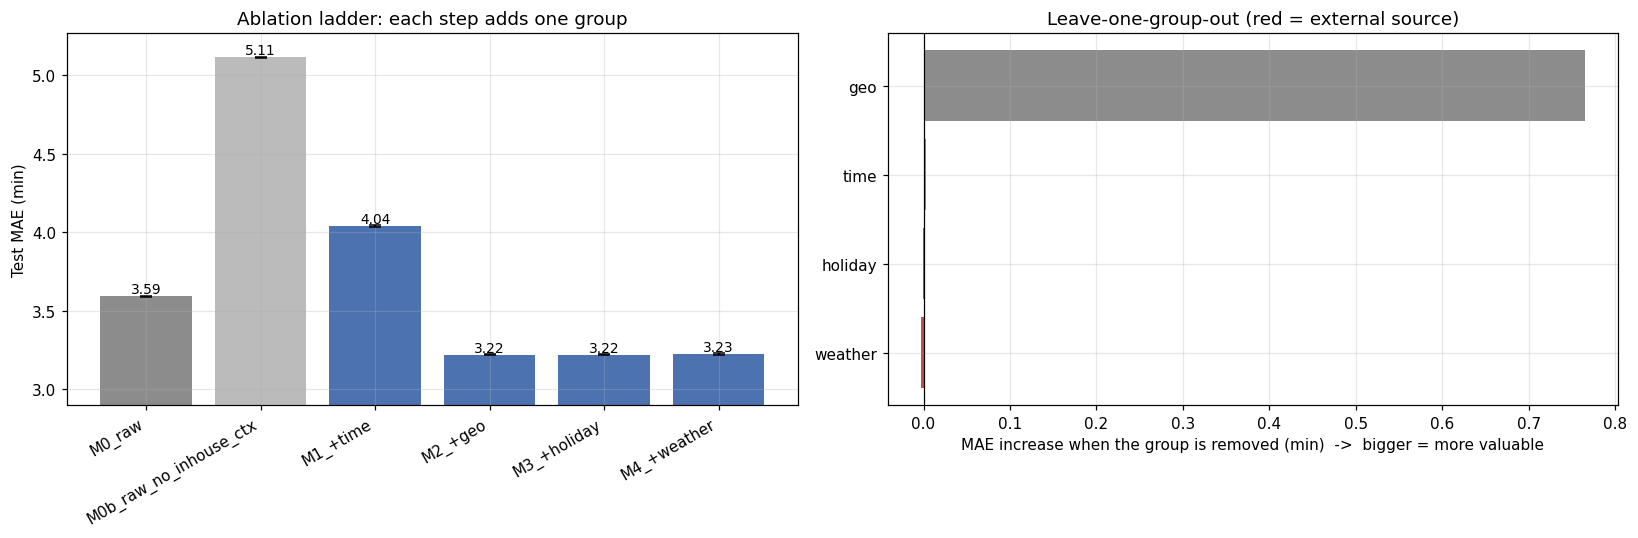

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

lad = results_df.loc[LADDER]
colors = ["#8C8C8C"] + ["#4C72B0"] * (len(LADDER) - 1)
colors[1] = "#BBBBBB"   # M0b (raw without in-house context) is a side branch
ax[0].bar(range(len(lad)), lad["MAE"], yerr=lad["MAE_seed_sd"], color=colors, capsize=4)
ax[0].set_xticks(range(len(lad))); ax[0].set_xticklabels(lad.index, rotation=30, ha="right")
ax[0].set_ylim(lad["MAE"].min() * 0.9, lad["MAE"].max() * 1.03)
ax[0].set_ylabel("Test MAE (min)"); ax[0].set_title("Ablation ladder: each step adds one group")
for i, v in enumerate(lad["MAE"]):
    ax[0].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

loo = results_df.loc[[k for k in results_df.index if k.startswith("LOO_")]].copy()
loo["hurt_when_removed"] = loo["MAE"] - results_df.loc[FULL, "MAE"]
loo = loo.sort_values("hurt_when_removed")
ax[1].barh([k.replace("LOO_full_minus_", "") for k in loo.index], loo["hurt_when_removed"],
           color=["#C44E52" if g.replace("LOO_full_minus_", "") in EXTERNAL else "#8C8C8C" for g in loo.index])
ax[1].axvline(0, color="k", lw=0.8)
ax[1].set_xlabel("MAE increase when the group is removed (min)  ->  bigger = more valuable")
ax[1].set_title("Leave-one-group-out (red = external source)")
plt.tight_layout(); savefig("ablation"); plt.show()

### 7b. Leave-one-group-out with CIs (tests H2)

Removing a group from the full model and measuring the damage is the cleanest estimate of that group's **unique** contribution, net of overlap with other groups (e.g., road distance vs haversine).

In [28]:
full_pred = RESULTS[FULL]["reg"]["p_test"]
loo_rows = []
for g in ["time", "geo"] + EXTERNAL:
    name = f"LOO_full_minus_{g}"
    d, lo, hi = day_block_bootstrap(y_te_reg, RESULTS[name]["reg"]["p_test"], full_pred, TEST_DAYS)
    loo_rows.append({"group": g, "external": g in EXTERNAL, "unique_dMAE": round(d, 3),
                     "CI95_low": round(lo, 3), "CI95_high": round(hi, 3), "significant": lo > 0})
LOO_DF = pd.DataFrame(loo_rows).set_index("group")
LOO_DF

,external,unique_dMAE,CI95_low,CI95_high,significant
group,,,,,
time,False,0.003,-0.006,0.009,False
geo,False,0.768,0.568,0.996,True
holiday,True,-0.001,-0.007,0.005,False
weather,True,-0.003,-0.009,0.002,False


### 7c. Grouped-by-day cross-validation (robustness and holiday coverage)

The temporal holdout is honest but covers only ~11 days, which may contain no holidays and little rain. As a second lens we run 5-fold CV where **whole days** are held out together, so every day, including Holi and rainy days, is tested exactly once. Not strictly forward-in-time, so it's a robustness check, not the primary criterion. Trees use the median best iteration from the holdout run (no early stopping).

In [29]:
def grouped_cv_mae(feats, n_iter, n_splits=SUCCESS["n_cv_folds"]):
    groups = df["order_date"].dt.strftime("%Y-%m-%d").values
    X = make_X(df, feats)
    maes = []
    for tr, te in GroupKFold(n_splits=n_splits).split(X, Y_REG, groups):
        m = lgb.LGBMRegressor(objective=REG_OBJECTIVE,
                              **{**BASE_PARAMS, "n_estimators": n_iter, "random_state": SEED})
        m.fit(X.iloc[tr], Y_REG[tr])
        maes.append(mean_absolute_error(Y_REG[te], m.predict(X.iloc[te])))
    return np.array(maes)

cv_base = grouped_cv_mae(EXPERIMENTS[BASELINE], RESULTS[BASELINE]["reg"]["best_iter"])
cv_full = grouped_cv_mae(EXPERIMENTS[FULL], RESULTS[FULL]["reg"]["best_iter"])
cv_df = pd.DataFrame({"raw_MAE": cv_base, "enriched_MAE": cv_full, "gain": cv_base - cv_full},
                     index=[f"fold{i+1}" for i in range(len(cv_base))]).round(3)
CV_FOLDS_WON = int((cv_df["gain"] > 0).sum())
display(cv_df)
print(f"Enriched wins {CV_FOLDS_WON}/{len(cv_df)} folds; mean relative gain "
      f"{100*cv_df['gain'].sum()/cv_df['raw_MAE'].sum():.1f}%")

,raw_MAE,enriched_MAE,gain
fold1,3.743,3.317,0.427
fold2,3.529,3.111,0.418
fold3,3.533,3.184,0.349
fold4,3.595,3.234,0.361
fold5,3.491,3.128,0.363


Enriched wins 5/5 folds; mean relative gain 10.7%


### 7d. What the full model relies on

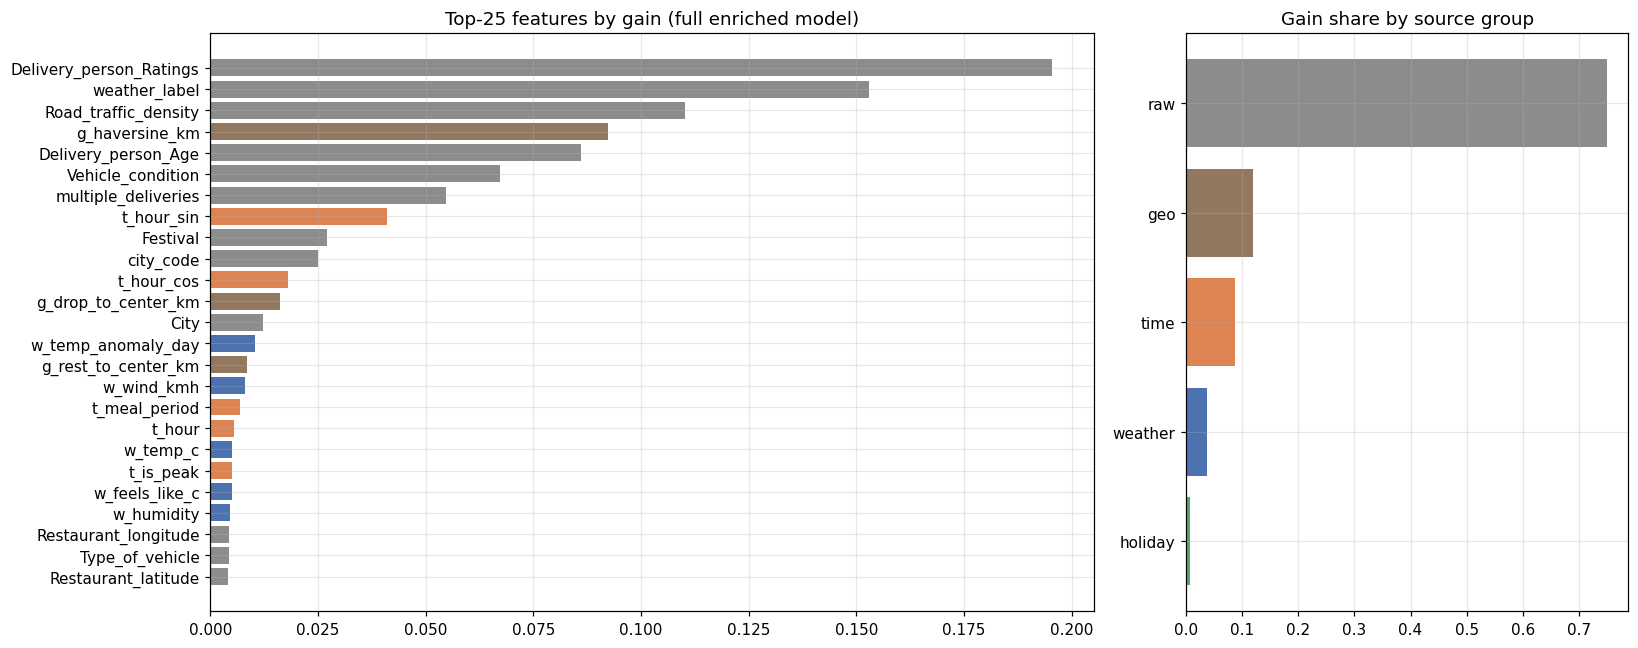

,gain_share
group,
raw,75.0%
geo,12.0%
time,8.6%
weather,3.7%
holiday,0.6%


In [30]:
imp = pd.DataFrame({f"s{i}": pd.Series(m.booster_.feature_importance("gain"), index=m.booster_.feature_name())
                    for i, m in enumerate(RESULTS[FULL]["reg"]["models"])}).mean(axis=1)
imp = (imp / imp.sum()).sort_values(ascending=False)
imp_df = pd.DataFrame({"gain_share": imp, "group": [FEAT2GROUP.get(f, "?") for f in imp.index]})

GROUP_COLORS = {"raw": "#8C8C8C", "time": "#DD8452", "geo": "#937860",
                "holiday": "#55A868", "weather": "#4C72B0", "road": "#C44E52"}
fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})
top = imp_df.head(25).iloc[::-1]
ax[0].barh(top.index, top["gain_share"], color=[GROUP_COLORS[g] for g in top["group"]])
ax[0].set_title("Top-25 features by gain (full enriched model)")
by_group = imp_df.groupby("group")["gain_share"].sum().sort_values()
ax[1].barh(by_group.index, by_group.values, color=[GROUP_COLORS[g] for g in by_group.index])
ax[1].set_title("Gain share by source group")
plt.tight_layout(); savefig("feature_importance"); plt.show()
by_group.sort_values(ascending=False).map("{:.1%}".format)

## 8. Where does enrichment help? Segment analysis

Averages hide the story. The pitch is usually *"your ETAs are fine on a normal Tuesday and badly wrong when it rains / on Holi / across the river"*. This table is the unbiased evidence for that (unlike the hand-picked cases in Section 9).

,n,MAE_raw,MAE_enriched,gain_min,gain_%,reliable
segment,,,,,,
All test orders,9447,3.59,3.23,0.37,10.22,yes
Raining at order hour (>=0.2 mm/h),59,3.42,3.21,0.22,6.30,low n
Rained in last 3 h,21,4.03,4.13,-0.09,-2.29,too small
Hot (feels like >=38 C),358,3.44,3.25,0.18,5.37,yes
Holiday +/-1 day,1637,3.41,3.03,0.38,11.11,yes
Ramadan iftar window,926,3.93,3.40,0.53,13.51,yes
Peak meal hours,3555,3.90,3.61,0.29,7.47,yes
Weekend,2170,3.52,3.20,0.33,9.27,yes
Traffic 'Jam' (in-house label),2976,3.88,3.58,0.30,7.64,yes


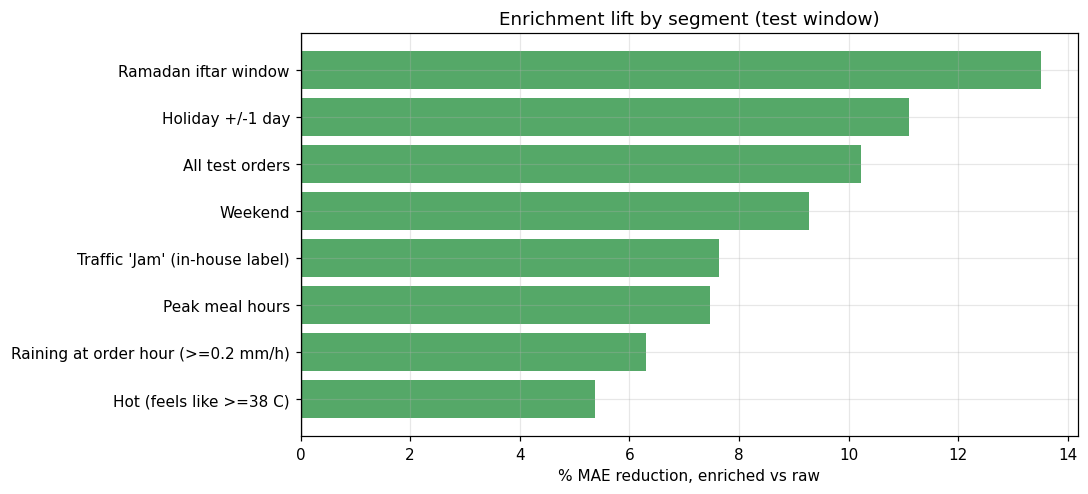

In [31]:
test["err_raw"] = np.abs(test["target_min"] - test[f"pred_{BASELINE}"])
test["err_full"] = np.abs(test["target_min"] - test[f"pred_{FULL}"])
test["gain"] = test["err_raw"] - test["err_full"]

def col(c):
    return test[c] if c in test.columns else pd.Series(np.nan, index=test.index)

SEGMENTS = {
    "All test orders":                    pd.Series(True, index=test.index),
    "Raining at order hour (>=0.2 mm/h)":  col("w_is_rain") == 1,
    "Heavy rain (>=2.5 mm/h)":             col("w_heavy_rain") == 1,
    "Rained in last 3 h":                 col("w_rained_last_3h") == 1,
    "Hot (feels like >=38 C)":             col("w_hot") == 1,
    "Holiday +/-1 day":                   col("h_in_window") == 1,
    "Ramadan iftar window":               col("h_iftar_window") == 1,
    "High detour (road/straight >=1.6)":   col("r_detour_ratio") >= 1.6,
    "Long trip (road >=10 km)":            col("r_road_km") >= 10,
    "Peak meal hours":                    col("t_is_peak") == 1,
    "Weekend":                            col("t_is_weekend") == 1,
    "Traffic 'Jam' (in-house label)":     col("Road_traffic_density") == "Jam",
}
seg_rows = []
for name, m in SEGMENTS.items():
    m = m.fillna(False).astype(bool)
    n = int(m.sum())
    if n == 0:
        continue
    mr, mf = test.loc[m, "err_raw"].mean(), test.loc[m, "err_full"].mean()
    seg_rows.append({"segment": name, "n": n, "MAE_raw": mr, "MAE_enriched": mf,
                     "gain_min": mr - mf, "gain_%": 100 * (mr - mf) / mr,
                     "reliable": "yes" if n >= 100 else ("low n" if n >= 30 else "too small")})
SEG_DF = pd.DataFrame(seg_rows).set_index("segment").round(2)
display(SEG_DF)

plot = SEG_DF[SEG_DF["reliable"] != "too small"].sort_values("gain_%")
plt.figure(figsize=(10, 0.45 * len(plot) + 1))
plt.barh(plot.index, plot["gain_%"], color=["#55A868" if v > 0 else "#C44E52" for v in plot["gain_%"]])
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("% MAE reduction, enriched vs raw"); plt.title("Enrichment lift by segment (test window)")
plt.tight_layout(); savefig("segments"); plt.show()

In [32]:
# City-level view: does the lift generalise, or is it one city?
city_view = (test.groupby("city_name")
                 .agg(n=("ID", "size"), MAE_raw=("err_raw", "mean"), MAE_enriched=("err_full", "mean"))
                 .assign(gain_pct=lambda t: 100 * (t.MAE_raw - t.MAE_enriched) / t.MAE_raw)
                 .query("n >= 50").sort_values("gain_pct", ascending=False).round(2))
print(f"Cities where enrichment helps: {(city_view['gain_pct'] > 0).sum()}/{len(city_view)}")
city_view

Cities where enrichment helps: 12/12


,n,MAE_raw,MAE_enriched,gain_pct
city_name,,,,
Pune,790,3.61,3.13,13.16
Mumbai,785,3.44,3.01,12.60
Surat,777,3.66,3.22,11.95
Hyderabad,787,3.55,3.13,11.82
Bengaluru,762,3.47,3.07,11.51
Coimbatore,772,3.54,3.15,11.06
Chennai,783,3.50,3.11,10.91
Mysuru,774,3.77,3.40,9.82
Jaipur,861,3.58,3.26,8.95


## 9. Case studies: individual orders

In [33]:
FULL_MODEL = RESULTS[FULL]["reg"]["models"][0]
FULL_FEATS = EXPERIMENTS[FULL]

def contributions(idx):
    X = make_X(test.loc[[idx]], FULL_FEATS)
    c = FULL_MODEL.predict(X, pred_contrib=True)[0]
    per_feat = pd.Series(c[:-1], index=FULL_FEATS)
    return per_feat, c[-1]

def show_case(idx, title):
    r = test.loc[idx]
    per_feat, bias = contributions(idx)
    by_group = per_feat.groupby(lambda f: FEAT2GROUP.get(f, "?")).sum().sort_values(key=np.abs, ascending=False)
    top = per_feat.reindex(per_feat.abs().sort_values(ascending=False).index).head(6)

    def fmt(v, spec=".1f"):
        return "n/a" if pd.isna(v) else format(v, spec)

    print("=" * 96)
    print(f"{title}   (order {r['ID']})")
    print("-" * 96)
    print(f"  {r['city_name']} | {r['order_ts']:%a %d %b %Y %H:%M} | {r['Type_of_order']} by {r['Type_of_vehicle']}"
          f" | in-house labels: weather={r['weather_label']}, traffic={r['Road_traffic_density']}, festival={r['Festival']}")
    print(f"  Weather (Open-Meteo): {fmt(r.get('w_precip_mm'), '.1f')} mm/h rain, "
          f"{fmt(r.get('w_precip_3h_mm'), '.1f')} mm in last 3 h, feels like {fmt(r.get('w_feels_like_c'), '.0f')} C")
    print(f"  Calendar: {r.get('h_name') or 'no holiday'} | days to next holiday {fmt(r.get('h_days_to_next'), '.0f')}"
          f" | Ramadan={int(r.get('h_is_ramadan', 0))}")
    if ROAD_ON:
        print(f"  Distance: straight {fmt(r.get('g_haversine_km'), '.2f')} km vs road {fmt(r.get('r_road_km'), '.2f')} km "
              f"(detour x{fmt(r.get('r_detour_ratio'), '.2f')}), OSRM free-flow {fmt(r.get('r_osrm_min'), '.0f')} min")
    print(f"\n  ACTUAL {r['target_min']:.0f} min | raw model {r[f'pred_{BASELINE}']:.1f} "
          f"(err {r['err_raw']:.1f}) | enriched {r[f'pred_{FULL}']:.1f} (err {r['err_full']:.1f})")
    print(f"  Enriched prediction = baseline {bias:.1f} + " +
          " + ".join(f"{g} {v:+.1f}" for g, v in by_group.items()))
    print("  Top drivers: " + ", ".join(f"{f} {v:+.1f}" for f, v in top.items()))

def pick(mask, how):
    sub = test[mask.fillna(False).astype(bool) & test["gain"].notna()]
    if sub.empty:
        return None
    if how == "best":
        return sub["gain"].idxmax()
    if how == "typical":
        return (sub["gain"] - sub["gain"].median()).abs().idxmin()
    return sub["gain"].idxmin()

CASE_SCENARIOS = {
    "Rain at order time":                  col("w_is_rain") == 1,
    "Holiday / festival window":           col("h_in_window") == 1,
    "Big road detour (river, rail, one-way)": col("r_detour_ratio") >= 1.8,
    "Weekend dinner peak":                 (col("t_is_peak") == 1) & (col("t_is_weekend") == 1),
}
SHOWN_CASES = []
for scen, m in CASE_SCENARIOS.items():
    for how in ["best", "typical"]:
        idx = pick(m, how)
        if idx is None:
            print(f"\n[{scen}] no orders in the test window for this scenario.")
            break
        show_case(idx, f"{scen}: {how.upper()} case")
        SHOWN_CASES.append({"scenario": scen, "kind": how, "order_id": test.loc[idx, "ID"],
                            "actual": test.loc[idx, "target_min"],
                            "raw_pred": round(test.loc[idx, f"pred_{BASELINE}"], 1),
                            "enriched_pred": round(test.loc[idx, f"pred_{FULL}"], 1)})

idx = pick(pd.Series(True, index=test.index), "worst")
show_case(idx, "COUNTER-CASE: where enrichment hurt the most")

Rain at order time: BEST case   (order 0xa79)
------------------------------------------------------------------------------------------------
  Mysuru | Tue 29 Mar 2022 19:15 | Drinks by motorcycle | in-house labels: weather=Cloudy, traffic=Jam, festival=No
  Weather (Open-Meteo): 0.2 mm/h rain, 0.2 mm in last 3 h, feels like 26 C
  Calendar: no holiday | days to next holiday 4 | Ramadan=0

  ACTUAL 48 min | raw model 37.6 (err 10.4) | enriched 44.3 (err 3.7)
  Enriched prediction = baseline 26.2 + raw +11.3 + geo +5.3 + time +1.4 + weather +0.0 + holiday +0.0
  Top drivers: g_haversine_km +4.8, weather_label +3.5, Vehicle_condition +3.0, Delivery_person_Age +2.9, Road_traffic_density +2.7, t_hour_sin +0.8
Rain at order time: TYPICAL case   (order 0x40fe)
------------------------------------------------------------------------------------------------
  Chennai | Fri 01 Apr 2022 10:25 | Buffet by scooter | in-house labels: weather=Sunny, traffic=Low, festival=No
  Weather (Open-Meteo):

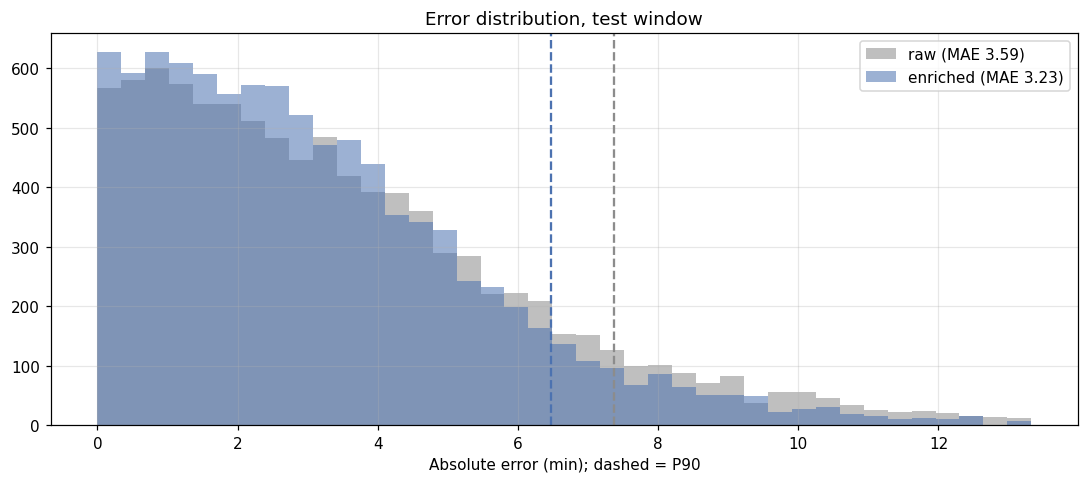

In [34]:
# Error distribution: does enrichment shrink the painful tail (what customers actually complain about)?
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.linspace(0, test[["err_raw", "err_full"]].quantile(0.99).max(), 40)
ax.hist(test["err_raw"], bins=bins, alpha=0.55, label=f"raw (MAE {test['err_raw'].mean():.2f})", color="#8C8C8C")
ax.hist(test["err_full"], bins=bins, alpha=0.55, label=f"enriched (MAE {test['err_full'].mean():.2f})", color="#4C72B0")
for q in [0.9]:
    ax.axvline(test["err_raw"].quantile(q), color="#8C8C8C", ls="--")
    ax.axvline(test["err_full"].quantile(q), color="#4C72B0", ls="--")
ax.set_xlabel("Absolute error (min); dashed = P90"); ax.legend(); ax.set_title("Error distribution, test window")
plt.tight_layout(); savefig("error_distribution"); plt.show()

## 10. Verdict against the pre-registered criteria

In [35]:
full_m, base_m = RESULTS[FULL], RESULTS[BASELINE]
rel_gain = (base_m["reg_m"]["MAE"] - full_m["reg_m"]["MAE"]) / base_m["reg_m"]["MAE"]
d, lo, hi = day_block_bootstrap(y_te_reg, base_m["reg"]["p_test"], full_m["reg"]["p_test"], TEST_DAYS)
f1_gain = full_m["clf_m"]["F1"] - base_m["clf_m"]["F1"]
ext_sig = LOO_DF[LOO_DF["external"] & LOO_DF["significant"]]

checks = pd.DataFrame([
    ("C1", "Relative MAE gain >= 5%",          f"{rel_gain:.1%}",                      rel_gain >= SUCCESS["min_rel_mae_gain"], "primary"),
    ("C2", "Bootstrap CI lower bound > 0",     f"{d:.3f} [{lo:.3f}, {hi:.3f}] min",   lo > 0,                                   "primary"),
    ("C3", "F1 gain >= +0.03",                 f"{f1_gain:+.3f}",                      f1_gain >= SUCCESS["min_f1_gain"],        "secondary"),
    ("C4", "Grouped-day CV folds won >= 4/5",  f"{CV_FOLDS_WON}/{SUCCESS['n_cv_folds']}", CV_FOLDS_WON >= SUCCESS["min_cv_folds_won"], "secondary"),
    ("C5", "An external group is significant", ", ".join(ext_sig.index) or "none",   len(ext_sig) > 0,                         "primary"),
], columns=["id", "criterion", "observed", "pass", "level"]).set_index("id")
display(checks)

primary_pass = checks.loc[checks["level"] == "primary", "pass"].all()
secondary_pass = checks.loc[checks["level"] == "secondary", "pass"].all()

h3_recovered = None
if "M0b_raw_no_inhouse_ctx" in results_df.index:
    lost = results_df.loc["M0b_raw_no_inhouse_ctx", "MAE"] - results_df.loc[BASELINE, "MAE"]
    regained = results_df.loc["M0b_raw_no_inhouse_ctx", "MAE"] - results_df.loc["M6_full_no_inhouse_ctx", "MAE"]
    h3_recovered = regained / lost if lost > 0 else np.nan
    print(f"H3: dropping in-house context costs {lost:+.3f} min MAE; external enrichment recovers "
          f"{regained:+.3f} min ({'n/a' if pd.isna(h3_recovered) else f'{h3_recovered:.0%}'} of the loss, "
          f"can exceed 100%).")

if primary_pass and secondary_pass:
    VERDICT = "PASS: enrichment clearly beats raw. Proceed to V1 (automate the winning sources)."
elif primary_pass:
    VERDICT = "PASS (primary only): real, external-driven lift; secondary checks weaker. Proceed, but widen validation."
elif rel_gain > 0 and len(ext_sig) == 0:
    VERDICT = ("FAIL on H2: gains come from derived features (time/geo), not external data. "
               "That is feature engineering, not an enrichment product. Rethink before building.")
else:
    VERDICT = "FAIL: enrichment does not clearly beat raw on this data. See Section 12 before drawing conclusions."
print("\nVERDICT:", VERDICT)
if not LABELS_LOOK_REAL:
    print("Context: this dataset's weather labels do not track real weather (Section 4d). A negative weather "
          "result here is weak evidence; validate on real operator logs.")

,criterion,observed,pass,level
id,,,,
C1,Relative MAE gain >= 5%,10.2%,True,primary
C2,Bootstrap CI lower bound > 0,"0.368 [0.327, 0.416] min",True,primary
C3,F1 gain >= +0.03,+0.018,False,secondary
C4,Grouped-day CV folds won >= 4/5,5/5,True,secondary
C5,An external group is significant,none,False,primary


H3: dropping in-house context costs +1.520 min MAE; external enrichment recovers +0.640 min (42% of the loss, can exceed 100%).

VERDICT: FAIL on H2: gains come from derived features (time/geo), not external data. That is feature engineering, not an enrichment product. Rethink before building.
Context: this dataset's weather labels do not track real weather (Section 4d). A negative weather result here is weak evidence; validate on real operator logs.


## 11. Export: the automation spec

This notebook is the specification for V1. The cell below turns what we *measured* into a machine-readable spec: for each source, its join key, granularity, coverage, unique lift, cost, and the production caveats we discovered along the way.

In [36]:
SOURCE_META = {
    "time": dict(kind="derived", provider="order timestamp", join_key="order_ts",
                 granularity="per order", call_pattern="none (pure function)",
                 prod_notes="Timezone handling; decide prediction point (order vs pickup) to avoid leaking prep time."),
    "geo": dict(kind="derived", provider="haversine + city centroid", join_key="restaurant & drop coordinates",
                granularity="per order", call_pattern="none (pure function)",
                prod_notes="Coordinate cleaning (sign flips, zeros, city mismatch) was required on the seed data."),
    "holiday": dict(kind="external", provider="python-holidays + curated regional festival calendar",
                    join_key="(date, state)", granularity="daily x state",
                    call_pattern="offline table, rebuilt yearly",
                    prod_notes="Lunar and regional festivals move every year; curated calendar needs an owner. "
                               "Add event data (cricket matches, local events) as a next source."),
    "weather": dict(kind="external", provider="Open-Meteo (archive for training, forecast API in production)",
                    join_key="(city or ~10 km geo-cell, hour ceiling)", granularity="hourly",
                    call_pattern="1 call per cell x date-range, cached",
                    prod_notes="Training used reanalysis; production must use forecasts issued before order time "
                               "(point-in-time correctness). Precip is hour-ending, so join on hour ceiling."),
    "road": dict(kind="external", provider="self-hosted OSRM on OpenStreetMap (car profile)",
                 join_key=f"(origin, destination) rounded to {COORD_DECIMALS} dp",
                 granularity="per coordinate pair", call_pattern="1 call per unique pair, cached",
                 prod_notes="Car profile approximates two-wheelers. Public demo server unusable at scale; self-host. "
                            "Cache hit rate grows with repeat restaurant-to-area pairs."),
}

top_feat = imp_df.reset_index().rename(columns={"index": "feature"}).groupby("group").first()["feature"]
spec = []
for g, meta in SOURCE_META.items():
    if not FEATURE_GROUPS.get(g):
        continue
    loo = LOO_DF.loc[g] if g in LOO_DF.index else None
    spec.append({
        "group": g, **meta,
        "features": FEATURE_GROUPS[g],
        "row_coverage": round(coverage.get(g, 0.0), 4),
        "unique_mae_gain_min": None if loo is None else float(loo["unique_dMAE"]),
        "unique_mae_gain_ci95": None if loo is None else [float(loo["CI95_low"]), float(loo["CI95_high"])],
        "significant": None if loo is None else bool(loo["significant"]),
        "gain_share_in_full_model": round(float(imp_df.loc[imp_df["group"] == g, "gain_share"].sum()), 4),
        "top_feature": top_feat.get(g),
        "recommendation": ("AUTOMATE" if (loo is not None and bool(loo["significant"]))
                           else "KEEP (cheap)" if meta["kind"] == "derived"
                           else "DEPRIORITISE (no measurable unique lift here)"),
    })

summary = {
    "study": "Delivery-delay enrichment V0",
    "dataset_rows": int(len(df)), "cities": int(df["city_code"].nunique()),
    "date_range": [str(df["order_date"].min().date()), str(df["order_date"].max().date())],
    "prediction_point": PREDICTION_POINT, "late_threshold_min": float(late_thr),
    "baseline": BASELINE, "full_model": FULL,
    "test_mae_raw": float(base_m["reg_m"]["MAE"]), "test_mae_enriched": float(full_m["reg_m"]["MAE"]),
    "relative_mae_gain": float(rel_gain), "mae_gain_ci95": [lo, hi],
    "f1_raw": float(base_m["clf_m"]["F1"]), "f1_enriched": float(full_m["clf_m"]["F1"]),
    "cv_folds_won": CV_FOLDS_WON, "h3_share_of_inhouse_loss_recovered":
        None if h3_recovered is None or pd.isna(h3_recovered) else float(h3_recovered),
    "dataset_weather_labels_look_real": bool(LABELS_LOOK_REAL),
    "verdict": VERDICT, "api_stats": API_STATS, "sources": spec, "cases": SHOWN_CASES,
}
(OUT_DIR / "enrichment_spec.json").write_text(json.dumps(summary, indent=2, default=str))

lines = ["# Enrichment spec (generated by V0 notebook)", "", f"**Verdict:** {VERDICT}", "",
         f"Test MAE raw {summary['test_mae_raw']:.2f} -> enriched {summary['test_mae_enriched']:.2f} min "
         f"({rel_gain:.1%}, 95% CI of gain [{lo:.2f}, {hi:.2f}] min).", "",
         "| Source | Kind | Join key | Coverage | Unique MAE gain (min) | Significant | Recommendation |",
         "|---|---|---|---|---|---|---|"]
for s in spec:
    gain = "n/a" if s["unique_mae_gain_min"] is None else f"{s['unique_mae_gain_min']:+.3f}"
    lines.append(f"| {s['group']} | {s['kind']} | {s['join_key']} | {s['row_coverage']:.0%} | {gain} | "
                 f"{s['significant']} | {s['recommendation']} |")
lines += ["", "## Production notes"] + [f"- **{s['group']}**: {s['prod_notes']}" for s in spec]
(OUT_DIR / "enrichment_spec.md").write_text("\n".join(lines))

print("\n".join(lines))
print(f"\nSaved: {sorted(p.name for p in OUT_DIR.iterdir())}")

# Enrichment spec (generated by V0 notebook)

**Verdict:** FAIL on H2: gains come from derived features (time/geo), not external data. That is feature engineering, not an enrichment product. Rethink before building.

Test MAE raw 3.59 -> enriched 3.23 min (10.2%, 95% CI of gain [0.33, 0.42] min).

| Source | Kind | Join key | Coverage | Unique MAE gain (min) | Significant | Recommendation |
|---|---|---|---|---|---|---|
| time | derived | order_ts | 100% | +0.003 | False | KEEP (cheap) |
| geo | derived | restaurant & drop coordinates | 92% | +0.768 | True | AUTOMATE |
| holiday | external | (date, state) | 100% | -0.001 | False | DEPRIORITISE (no measurable unique lift here) |
| weather | external | (city or ~10 km geo-cell, hour ceiling) | 100% | -0.003 | False | DEPRIORITISE (no measurable unique lift here) |

## Production notes
- **time**: Timezone handling; decide prediction point (order vs pickup) to avoid leaking prep time.
- **geo**: Coordinate cleaning (sign flips, zeros, cit

## 12. How to read the outcome, and what comes next

**If the verdict is PASS.** The spec in `outputs/enrichment_spec.md` is the V1 backlog, in order of measured unique lift. The case cards from Section 9 plus `segments.png` and `ablation.png` are the demo. The pitch line writes itself from Section 8: *"X % better overall, Y % better when it rains / on festival days / on high-detour routes."*

**If it fails, diagnose before abandoning:**

| Symptom | Likely cause | Next step |
|---|---|---|
| Gains only from `time`/`geo` (C5 fails) | The value is feature engineering, not data | Reposition (ETA modelling service?) or find sources customers can't build themselves |
| In-house weather labels don't track real rain (Section 4d) | Seed dataset is synthetic; target doesn't depend on real weather | Re-run on real logs from a design partner before concluding anything about weather |
| Test window has no holidays / little rain | Coverage, not signal (Feb–Apr is dry season in most of India) | Rely on grouped-day CV; get a dataset spanning monsoon and Diwali |
| Road features add nothing over haversine | Short, grid-like trips, or noisy coordinates | Check coordinate quality; OSRM may only matter in specific cities (see city table) |
| Big lift but wide CI | Too few test days | Longer history; the CI width is the argument for a pilot |

**Candidate sources for V0.5** (same harness, one more group each): live traffic (commercial APIs), air quality/visibility (winter fog in the north), cricket match schedules (IPL evenings), local events, and restaurant-level prep-time history (derived, but a strong baseline to beat).

**What to automate first, based on this notebook:** (1) coordinate cleaning and city/geo-cell resolution, (2) point-in-time weather join (forecast API, hour-ceiling alignment), (3) holiday/festival calendar service with a curation workflow, (4) self-hosted routing with a pair cache, (5) this exact ablation harness as a customer-facing *"lift report"*, which is the product's sales tool.

In [37]:
import shutil
from google.colab import files

# Zip the outputs directory
shutil.make_archive("outputs_archive", "zip", OUT_DIR)

# Download the zipped file
files.download("outputs_archive.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>